## 📊 Big Data Analytics for Retail Demand

This project focuses on analyzing retail demand patterns using Python, Pandas, and SQLite. It demonstrates the core concepts of ETL (Extract, Transform, Load) by processing and transforming retail data into meaningful insights.

Instead of handling large-scale datasets, this project simulates Big Data processing using efficient Pandas operations such as groupby, which mimics the MapReduce concept.

The analysis explores sales trends across product categories, countries, customer segments, and time (monthly trends). Aggregated results are stored in a SQLite database and queried using SQL to demonstrate real-world data processing workflows.

Overall, this project highlights how Big Data concepts can be applied on smaller datasets to gain valuable business insights.

**Tools Used:** Python, Pandas, SQLite, Matplotlib, Jupyter Notebook

In [43]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('Retail Dataset.csv')

In [45]:
df.head()

,Country,Age,Gender,Customer_Segment,Date,Year,Month,Total_Purchases,Total_Amount,Product_Category,Product_Brand,Product_Type,Payment_Method
0,Germany,21.0,Male,Regular,9/18/2023,2023.0,September,3.0,324.086270,Clothing,Nike,Shorts,Debit Card
1,UK,19.0,Female,Premium,12/31/2023,2023.0,December,2.0,806.707815,Electronics,Samsung,Tablet,Credit Card
2,Australia,48.0,Male,Regular,4/26/2023,2023.0,April,3.0,1063.432799,Books,Penguin Books,Children's,Credit Card
3,Canada,56.0,Male,Premium,05-08-2023,2023.0,May,7.0,2466.854021,Home Decor,Home Depot,Tools,PayPal
4,UK,22.0,Male,Premium,01-10-2024,2024.0,January,2.0,248.553049,Grocery,Nestle,Chocolate,Cash


In [46]:
df.describe()

,Age,Year,Total_Purchases,Total_Amount
count,301837.000000,301660.000000,301649.000000,301660.000000
mean,35.481326,2023.165113,5.359729,1367.651156
std,15.021933,0.371283,2.868575,1128.998515
min,18.000000,2023.000000,1.000000,10.003750
25%,22.000000,2023.000000,3.000000,438.724278
50%,32.000000,2023.000000,5.000000,1041.117547
75%,46.000000,2023.000000,8.000000,2029.999853
max,70.000000,2024.000000,10.000000,4999.625796


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Country           301739 non-null  object 
 1   Age               301837 non-null  float64
 2   Gender            301693 non-null  object 
 3   Customer_Segment  301795 non-null  object 
 4   Date              301651 non-null  object 
 5   Year              301660 non-null  float64
 6   Month             301737 non-null  object 
 7   Total_Purchases   301649 non-null  float64
 8   Total_Amount      301660 non-null  float64
 9   Product_Category  301727 non-null  object 
 10  Product_Brand     301729 non-null  object 
 11  Product_Type      302010 non-null  object 
 12  Payment_Method    301713 non-null  object 
dtypes: float64(4), object(9)
memory usage: 30.0+ MB


In [48]:
df = df.dropna()

In [49]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)


In [50]:
df['Year'] = df['Year'].astype(int)
df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month
df['Total_Purchases'] = df['Total_Purchases'].astype(int)


In [51]:
df['Avg_Order_Value'] = df['Total_Amount'] / df['Total_Purchases']

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298494 entries, 0 to 302009
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Country           298494 non-null  object        
 1   Age               298494 non-null  float64       
 2   Gender            298494 non-null  object        
 3   Customer_Segment  298494 non-null  object        
 4   Date              298494 non-null  datetime64[ns]
 5   Year              298494 non-null  int64         
 6   Month             298494 non-null  int32         
 7   Total_Purchases   298494 non-null  int64         
 8   Total_Amount      298494 non-null  float64       
 9   Product_Category  298494 non-null  object        
 10  Product_Brand     298494 non-null  object        
 11  Product_Type      298494 non-null  object        
 12  Payment_Method    298494 non-null  object        
 13  Avg_Order_Value   298494 non-null  float64       
dtypes: dateti

In [53]:
df['Age'] = df['Age'].astype(int)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298494 entries, 0 to 302009
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Country           298494 non-null  object        
 1   Age               298494 non-null  int64         
 2   Gender            298494 non-null  object        
 3   Customer_Segment  298494 non-null  object        
 4   Date              298494 non-null  datetime64[ns]
 5   Year              298494 non-null  int64         
 6   Month             298494 non-null  int32         
 7   Total_Purchases   298494 non-null  int64         
 8   Total_Amount      298494 non-null  float64       
 9   Product_Category  298494 non-null  object        
 10  Product_Brand     298494 non-null  object        
 11  Product_Type      298494 non-null  object        
 12  Payment_Method    298494 non-null  object        
 13  Avg_Order_Value   298494 non-null  float64       
dtypes: dateti

In [55]:
df = df[df['Year'] == 2023]

In [56]:
category_sales = df.groupby('Product_Category')['Total_Amount'].sum().reset_index()
display(category_sales)
       

,Product_Category,Total_Amount
0,Books,6.171462e+07
1,Clothing,6.216900e+07
2,Electronics,8.064491e+07
3,Grocery,7.522379e+07
4,Home Decor,6.125148e+07


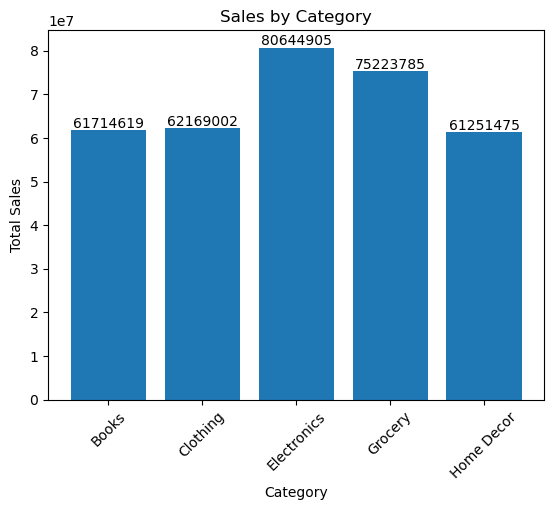

In [57]:
plt.figure()
bars = plt.bar(category_sales['Product_Category'], category_sales['Total_Amount'])

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), 
             ha='center', va='bottom')

plt.show()

In [58]:
monthly_sales = df.groupby(['Year','Month'])['Total_Amount'].sum().reset_index()
display(monthly_sales)

,Year,Month,Total_Amount
0,2023,1,2.079548e+07
1,2023,2,3.789377e+05
2,2023,3,2.595493e+07
3,2023,4,5.095869e+07
4,2023,5,3.614210e+07
5,2023,6,2.469376e+07
6,2023,7,3.914699e+07
7,2023,8,4.177270e+07
8,2023,9,2.515139e+07
9,2023,10,2.570658e+07


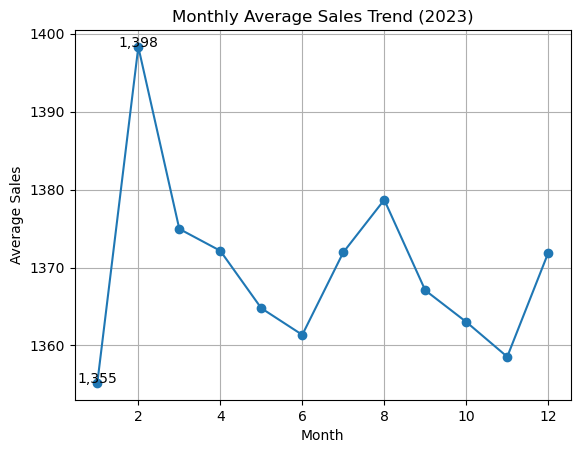

In [59]:
monthly_sales = df.groupby(['Year','Month'])['Total_Amount'].mean().reset_index()
monthly_sales = monthly_sales.sort_values('Month')

plt.figure()
plt.plot(monthly_sales['Month'], monthly_sales['Total_Amount'], marker='o')

plt.title('Monthly Average Sales Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Average Sales')

max_row = monthly_sales.loc[monthly_sales['Total_Amount'].idxmax()]
min_row = monthly_sales.loc[monthly_sales['Total_Amount'].idxmin()]

plt.text(max_row['Month'], max_row['Total_Amount'], f"{int(max_row['Total_Amount']):,}", ha='center')
plt.text(min_row['Month'], min_row['Total_Amount'], f"{int(min_row['Total_Amount']):,}", ha='center')

plt.grid()
plt.show()

In [60]:
country_sales = df.groupby('Country')['Total_Amount'].sum().reset_index()
display(country_sales)

,Country,Total_Amount
0,Australia,5.136147e+07
1,Canada,5.102154e+07
2,Germany,5.972391e+07
3,UK,7.161365e+07
4,USA,1.072832e+08


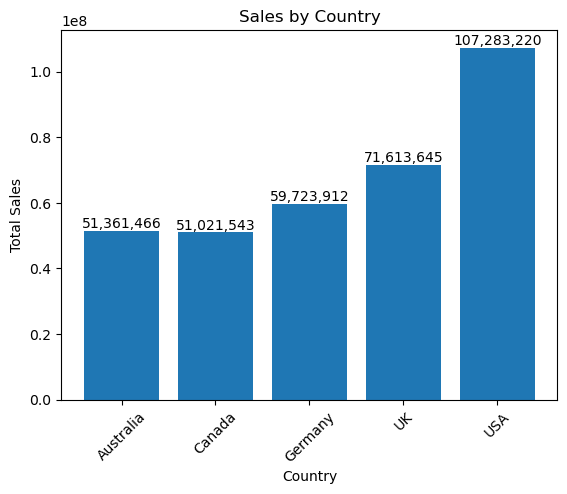

In [61]:
plt.figure()
bars = plt.bar(country_sales['Country'], country_sales['Total_Amount'])

plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', 
             ha='center', va='bottom')

plt.show()

In [62]:
segment_sales = df.groupby('Customer_Segment')['Total_Amount'].sum().reset_index()
display(segment_sales)

,Customer_Segment,Total_Amount
0,New,1.030026e+08
1,Premium,7.248976e+07
2,Regular,1.655114e+08


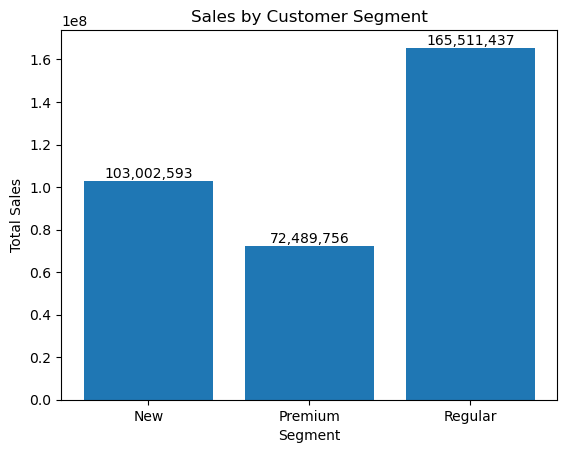

In [63]:
plt.figure()
bars = plt.bar(segment_sales['Customer_Segment'], segment_sales['Total_Amount'])

plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', 
             ha='center', va='bottom')

plt.show()

In [64]:
payment_sales = df.groupby('Payment_Method')['Total_Amount'].sum().reset_index()
display(payment_sales)

,Payment_Method,Total_Amount
0,Cash,8.310263e+07
1,Credit Card,1.022088e+08
2,Debit Card,8.673756e+07
3,PayPal,6.895478e+07


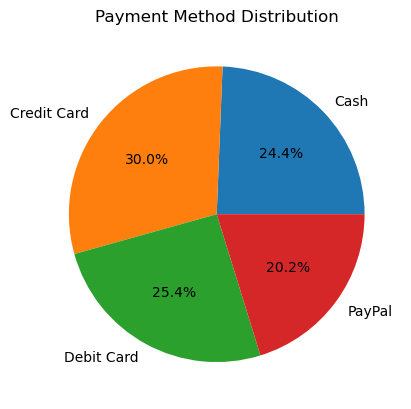

In [65]:
plt.figure()
plt.pie(payment_sales['Total_Amount'], 
        labels=payment_sales['Payment_Method'], 
        autopct='%1.1f%%')

plt.title('Payment Method Distribution')
plt.show()

In [66]:

conn = sqlite3.connect('retail_analysis.db')

df.to_sql('raw_data', conn, if_exists='replace', index=False)
category_sales.to_sql('category_sales', conn, if_exists='replace', index=False)
monthly_sales.to_sql('monthly_sales', conn, if_exists='replace', index=False)
country_sales.to_sql('country_sales', conn, if_exists='replace', index=False)
segment_sales.to_sql('segment_sales', conn, if_exists='replace', index=False)
payment_sales.to_sql('payment_sales', conn, if_exists='replace', index=False)

conn.close()

In [67]:
conn = sqlite3.connect('retail_analysis.db')

query1 = """
SELECT Product_Category, SUM(Total_Amount) AS Total_Sales
FROM raw_data
GROUP BY Product_Category
ORDER BY Total_Sales DESC
"""

In [68]:


from IPython.display import display

print("Category Sales (SQL)")
display(pd.read_sql(query1, conn))

Category Sales (SQL)


,Product_Category,Total_Sales
0,Electronics,8.064491e+07
1,Grocery,7.522379e+07
2,Clothing,6.216900e+07
3,Books,6.171462e+07
4,Home Decor,6.125148e+07


In [69]:
conn.close()

## 📌 Conclusion

This project successfully demonstrates how Big Data concepts can be applied using a manageable retail dataset. Through the implementation of the ETL (Extract, Transform, Load) process, raw data was cleaned, transformed, and analyzed to extract meaningful insights.

Using Pandas, aggregation operations such as groupby were performed to simulate MapReduce, enabling efficient analysis of sales trends across product categories, countries, customer segments, and time. The use of average monthly sales helped address data imbalance and provided a clearer understanding of demand patterns.

Furthermore, SQLite was used to store processed data and perform SQL queries, demonstrating how structured data can be managed and analyzed in a real-world environment.

Overall, the project highlights the importance of data preprocessing, aggregation, and querying in understanding retail demand, and shows how Big Data principles can be effectively implemented using simple tools.